In [2]:
import matplotlib.pyplot as plt
import open3d as o3d
import numpy as np
import json
import os

import pyFM.spectral as spectral
from pyFM.mesh import TriMesh

from tqdm.auto import tqdm
import meshplot as mp

import polyscope as ps
ps.init()


# Setting up Plotting Functions
def double_plot_o3d(myMesh1,myMesh2,cmap1=None,cmap2=None):
    vertlist_1 = np.asarray(myMesh1.vertices)
    facelist_1 = np.asarray(myMesh1.triangles)

    vertlist_2 = np.asarray(myMesh2.vertices)
    facelist_2 = np.asarray(myMesh2.triangles)
    
    d = mp.subplot(vertlist_1, facelist_1, c=cmap1, s=[2, 2, 0])
    mp.subplot(vertlist_2, facelist_2, c=cmap2, s=[2, 2, 1], data=d)
    
def double_plot(myMesh1,myMesh2,cmap1=None,cmap2=None):
    d = mp.subplot(myMesh1.vertlist, myMesh1.facelist, c=cmap1, s=[2, 2, 0])
    mp.subplot(myMesh2.vertlist, myMesh2.facelist, c=cmap2, s=[2, 2, 1], data=d)

def visu(vertices):
    min_coord,max_coord = np.min(vertices,axis=0,keepdims=True),np.max(vertices,axis=0,keepdims=True)
    cmap = (vertices-min_coord)/(max_coord-min_coord)
    return cmap

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.6 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.3


In [3]:
def processed_TriMesh(mesh):

    # clean mesh
    mesh.remove_duplicated_vertices()
    mesh.remove_degenerate_triangles()
    mesh.remove_unreferenced_vertices()

    verts, faces = np.asarray(mesh.vertices), np.asarray(mesh.triangles)
    
    # Create a TriMesh
    mesh_pyfm = TriMesh(verts, faces, area_normalize=True, center=True)
    mesh_pyfm.process(k=150, intrinsic=True) # why is this section so hard to process!!!!

    return mesh_pyfm

def initial_p2p_map(verts_i, verts_j):

    pcd_j = o3d.geometry.PointCloud() # create pointcloud
    pcd_j.points = o3d.utility.Vector3dVector(verts_j) # assign verts with normals to cloud

    kdtree = o3d.geometry.KDTreeFlann(pcd_j)
    
    p2p_ji = []
    for vert_i in verts_i:
        [_, idx, _] = kdtree.search_knn_vector_3d(vert_i, 1)
        p2p_ji.append(idx[0])

    p2p_ji = np.array(p2p_ji)
    return p2p_ji

def create_intial_maps_dict(meshes, K=30):
    inital_maps_dict = {}
    n_meshes = len(meshes)

    for i in tqdm(range(n_meshes), 'Creating Intial Maps Dictionary'):
        for j in range(n_meshes):
            if i == j: 
                continue # skip self-maps

            mesh_i, mesh_j = meshes[i], meshes[j]

            verts_i, verts_j = np.asarray(mesh_i.vertices), np.asarray(mesh_j.vertices)
            p2p_ji = initial_p2p_map(verts_j, verts_i)

            # Convert to functional map
            FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, mesh_i, mesh_j, dims=K)
        
            # Populate the dictionary
            inital_maps_dict[(i, j)] = FM_ij

    return inital_maps_dict

path = os.path.abspath('render_meshes_10')

start_frame = 1
end_frame = 10
frames = [str(i).zfill(4) for i in range(start_frame, end_frame + 1)]

mesh_list = [processed_TriMesh(o3d.io.read_triangle_mesh(f'{path}/render_frame_{frame}.ply')) for frame in tqdm(frames, "Loading and Processing Meshes")]
maps_dict = create_intial_maps_dict(mesh_list)

Loading and Processing Meshes:   0%|          | 0/10 [00:00<?, ?it/s]

Creating Intial Maps Dictionary:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
from FMN_Edited import FMN_Edited

## add parameters for interval size, alpha and beta for the weight boost

# Build the network
fmn_model = FMN_Edited(mesh_list, maps_dict)
fmn_model.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True, weight_type='new',
                    M_init=None, cclb_ratio=.9, n_jobs=1, equals_id=False,
                    verbose=True, alpha=0.3, beta=2.0, interval=2)

Setting 90 edges on 10 nodes.
Computing a 3000-sized subsample for each mesh


  0%|          | 0/24 [00:00<?, ?it/s]

In [ ]:
# To Save or Load Model
import pickle as p

# #save
with open("../../fmn_model_10_w_decay.pkl", "wb") as f:
    p.dump(fmn_model, f)

# load
# with open("../../fmn_model_10.pkl", "rb") as f:
#     fmn_model = p.load(f)

new map shape: (78, 78)


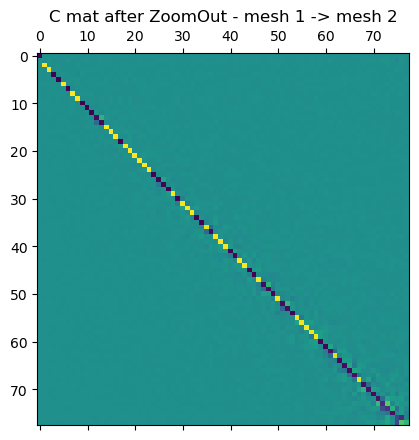

In [17]:
# For Display
def fm_display(ind_1, ind_2, meshes, maps, mesh_display=False):
    
    mesh1, mesh2 = meshes[ind_1], meshes[ind_2]
    fm_12 = maps[(ind_1, ind_2)]
    
    print(f"new map shape: {fm_12.shape}")
    plt.matshow(fm_12)
    plt.title(f"C mat after ZoomOut - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()

    if mesh_display:
        p2p_21 = spectral.convert.mesh_FM_to_p2p(fm_12, mesh1, mesh2) # need to look at this function properly

        cmap_1 = visu(mesh1.vertlist)
        cmap_2 = cmap_1[p2p_21]
        double_plot(mesh1, mesh2, cmap_1, cmap_2)

ind_1 = 0
ind_2 = 1
new_maps_dict = fmn_model.maps

fm_display(ind_1, ind_2, mesh_list, new_maps_dict)


In [12]:
def load_gt_from_json(output_path, frame):
    """Loads ray-traced ground-truth hit points from 4 cameras for a given frame."""
    all_points = []
    for i in range(4):
        cam_path = os.path.join(output_path, f"Camera_{i+1}", f"frame_{frame}.json")
        if not os.path.exists(cam_path):
            print(f"Warning: Missing {cam_path}")
            continue

        with open(cam_path, 'r') as f:
            camera_hit_list = json.load(f)

        hit_points = np.array([entry['hit'] for entry in camera_hit_list if entry['hit'] is not None], dtype=np.float32)
        all_points.append(hit_points)

    if len(all_points) == 0:
        raise RuntimeError(f"No valid GT data found for frame {frame}")

    # Combine all camera views
    combined_points = np.vstack(all_points)
    gt_pcd = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(combined_points))
    gt_pcd = gt_pcd.voxel_down_sample(voxel_size=0.005)
    gt_pcd.estimate_normals()
    return gt_pcd

def evaluate_map(mesh_source, mesh_target, p2p_map, gt_source_pcd, gt_target_pcd):
    """Compares mapped points to nearest ground-truth positions using Euclidean distance."""
    src_points = np.asarray(mesh_source.vertices)
    tgt_points = np.asarray(mesh_target.vertices)

    # Apply functional map to get mapped vertex positions
    mapped_points = tgt_points[p2p_map]

    # Build KDTree on ground-truth target
    gt_tree = o3d.geometry.KDTreeFlann(gt_target_pcd)

    errors = []
    for p in mapped_points:
        _, idx, _ = gt_tree.search_knn_vector_3d(p, 1)
        nearest = np.asarray(gt_target_pcd.points)[idx[0]]
        errors.append(np.linalg.norm(p - nearest))

    return np.mean(errors), np.std(errors), np.array(errors)



In [ ]:
# Do NOT RUn this need to figure out what its doing and then break it up properly
def benchmark_fmn(mesh_list, maps_dict, gt_path):
    from pyfm import functional_map_network as FMN  # Original
    from FMN_Edited import FMN_Edited  # Your modified version

    # Run original pyFM CZ
    print("\nRunning original pyFM Consistent ZoomOut...")
    fmn_orig = FMN.FunctionalMapNetwork(mesh_list, maps_dict)
    fmn_orig.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True)
    orig_maps = fmn_orig.p2p

    # Run your modified FMN
    print("\nRunning modified FMN_Edited...")
    fmn_mod = FMN_Edited(mesh_list, maps_dict)
    fmn_mod.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True, 
                           weight_type='new', M_init=None, cclb_ratio=.9, 
                           n_jobs=1, equals_id=False, verbose=True, 
                           alpha=0.3, beta=2.0, interval=2)
    mod_maps = fmn_mod.p2p

    # Evaluate across consecutive frames
    results = []
    for i in range(len(mesh_list) - 1):
        frame_src = str(i + 1).zfill(4)
        frame_tgt = str(i + 2).zfill(4)

        print(f"\nEvaluating {frame_src} → {frame_tgt}...")

        gt_src = load_gt_from_json(gt_path, frame_src)
        gt_tgt = load_gt_from_json(gt_path, frame_tgt)

        mean_orig, std_orig, _ = evaluate_map(mesh_list[i], mesh_list[i+1], orig_maps[(i, i+1)], gt_src, gt_tgt)
        mean_mod, std_mod, _  = evaluate_map(mesh_list[i], mesh_list[i+1], mod_maps[(i, i+1)], gt_src, gt_tgt)

        results.append({
            "pair": f"{frame_src}→{frame_tgt}",
            "original_mean": mean_orig,
            "original_std": std_orig,
            "modified_mean": mean_mod,
            "modified_std": std_mod
        })

        print(f"  Original CZ: mean={mean_orig:.4f}, std={std_orig:.4f}")
        print(f"  Modified CZ: mean={mean_mod:.4f}, std={std_mod:.4f}")

    return results


# -----------------------------------------------------------------------------------
# Step 4 — Main execution
# -----------------------------------------------------------------------------------

if __name__ == "__main__":
    from your_module import processed_TriMesh, create_intial_maps_dict  # adjust as needed

    path = "/Capstone/meshes"
    gt_path = "/Capstone/ground_truth"

    start_frame, end_frame = 1, 10
    frames = [str(i).zfill(4) for i in range(start_frame, end_frame + 1)]

    print("Loading and processing meshes...")
    mesh_list = [processed_TriMesh(o3d.io.read_triangle_mesh(f"{path}/render_frame_{frame}.ply")) for frame in tqdm(frames)]
    maps_dict = create_intial_maps_dict(mesh_list)

    results = benchmark_fmn(mesh_list, maps_dict, gt_path)

    print("\n=== Summary of Results ===")
    for r in results:
        print(f"{r['pair']}:  Original={r['original_mean']:.4f} | Modified={r['modified_mean']:.4f}")
